# 1) Effects of outliers on linear regression model

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data points
x = np.array([1, 2, 3, 4, 5])
y = np.array([5, 30, 20, 40, 60])

df = pd.DataFrame({"X": x, "Y": y})
print(df.to_string(index=False))


 X  Y
 1  5
 2 30
 3 20
 4 40
 5 60


# Lets find the line that minimizes the RSS error term

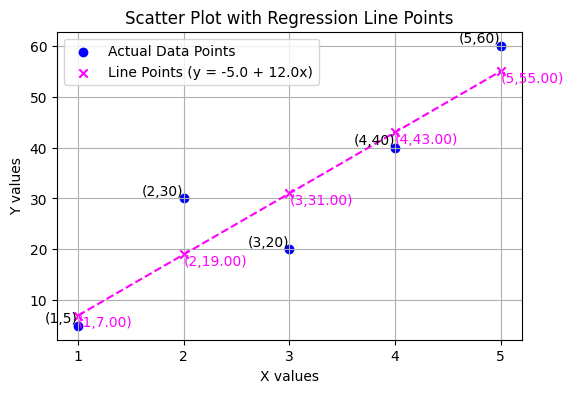

Original Data Points:
(1, 5)
(2, 30)
(3, 20)
(4, 40)
(5, 60)

Line Points (y = -5.0 + 12.0x):
(1, 7.0)
(2, 19.0)
(3, 31.0)
(4, 43.0)
(5, 55.0)

Table of Errors:
X    Actual Y  Predicted Y    Error Term (Squared)
--------------------------------------------------
1    5         7.0            4.00                
2    30        19.0           121.00              
3    20        31.0           121.00              
4    40        43.0           9.00                
5    60        55.0           25.00               

Residual Sum of Squares (RSS): 280.00


In [2]:
# Now lets find the actual line that minimizes the RSS
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x.reshape(-1, 1), y)

b = model.intercept_ # calculate intercept
m = model.coef_[0] # calculate slope

# Calculate y values for the line only at given x values
line_eq = f"y = {b} + {m}x"
color = "magenta"
y_line = b + m * x

# Create the plot
plt.figure(figsize=(6, 4))

# Scatter plot of actual data points
plt.scatter(x, y, color='blue', label='Actual Data Points', marker='o')

# Scatter plot for y = 10x + 5 at given x values
plt.scatter(x, y_line, color=color, label=f'Line Points ({line_eq})', marker='x')

# Connect the red points to form a line
plt.plot(x, y_line, color=color, linestyle='--')

# Annotate each point
for i in range(len(x)):
    plt.text(x[i], y[i], f"({x[i]},{y[i]})", fontsize=10, verticalalignment='bottom', horizontalalignment='right')
    plt.text(x[i], y_line[i], f"({x[i]},{y_line[i]:.2f})", fontsize=10, verticalalignment='top', horizontalalignment='left', color=color)

# Set only actual x values on the x-axis
plt.xticks(x)

# Labels, title, and legend
plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Scatter Plot with Regression Line Points")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Print table of original and predicted values
print("Original Data Points:")
print("\n".join(f"({x[i]}, {y[i]})" for i in range(len(x))))

print(f"\nLine Points ({line_eq}):")
print("\n".join(f"({x[i]}, {y_line[i]})" for i in range(len(x))))

# Compute RSS error terms
errors = (y - y_line) ** 2
RSS = np.sum(errors)  # Residual Sum of Squares

# Print error table
print("\nTable of Errors:")
print(f"{'X':<5}{'Actual Y':<10}{'Predicted Y':<15}{'Error Term (Squared)':<20}")
print("-" * 50)
for i in range(len(x)):
    print(f"{x[i]:<5}{y[i]:<10}{y_line[i]:<15}{errors[i]:<20.2f}")

# Print total RSS
print(f"\nResidual Sum of Squares (RSS): {RSS:.2f}")


# Explanation of above
The above error terms are calulcated as follows:

error1 = (actual_y1 - predicted_y1)^2 = 4

error2 = (actual_y2 - predicted_y2)^2 = 121  (and so on)

error3 = (actual_y3 - predicted_y3)^2 = 121

error4 = (actual_y4 - predicted_y4)^2 = 9

error5 = (actual_y5 - predicted_y5)^2 = 25

RSS = error1 + error2 + error3 + error4 + error5 = 280

### This line has the minimum RSS among all possible linear lines.

#### Lets add 1 outlier point: (6,10) and see how much line changes


 X  Y
 1  5
 2 30
 3 20
 4 40
 5 60
 6 10
#################################


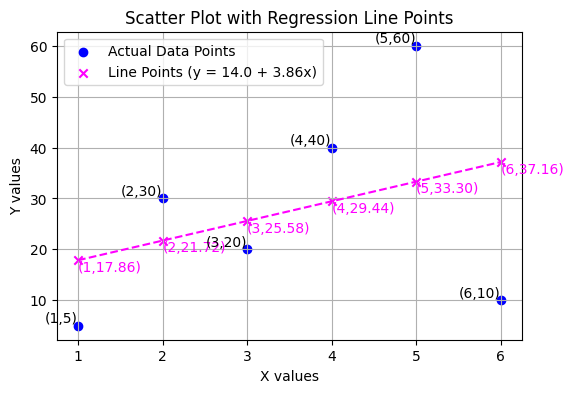

Original Data Points:
(1, 5)
(2, 30)
(3, 20)
(4, 40)
(5, 60)
(6, 10)

Line Points (y = 14.0 + 3.86x):
(1, 17.86)
(2, 21.72)
(3, 25.58)
(4, 29.44)
(5, 33.30)
(6, 37.16)

Table of Errors:
X    Actual Y  Predicted Y    Error Term (Squared)
--------------------------------------------------
1    5         17.86          165.38              
2    30        21.72          68.56               
3    20        25.58          31.14               
4    40        29.44          111.51              
5    60        33.30          712.89              
6    10        37.16          737.67              

Residual Sum of Squares (RSS): 1827.14


In [11]:
# Data points
x = np.array([1, 2, 3, 4, 5, 6])
y = np.array([5, 30, 20, 40, 60, 10])

df = pd.DataFrame({"X": x, "Y": y})
print(df.to_string(index=False))
print("#################################")

# Now lets find the actual line that minimizes the RSS
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x.reshape(-1, 1), y)

b = round(model.intercept_,2) # calculate intercept
m = round(model.coef_[0],2) # calculate slope

# Calculate y values for the line only at given x values
line_eq = f"y = {b} + {m}x"
color = "magenta"
y_line = b + m * x

# Create the plot
plt.figure(figsize=(6, 4))

# Scatter plot of actual data points
plt.scatter(x, y, color='blue', label='Actual Data Points', marker='o')

# Scatter plot for y = 10x + 5 at given x values
plt.scatter(x, y_line, color=color, label=f'Line Points ({line_eq})', marker='x')

# Connect the red points to form a line
plt.plot(x, y_line, color=color, linestyle='--')

# Annotate each point
for i in range(len(x)):
    plt.text(x[i], y[i], f"({x[i]},{y[i]})", fontsize=10, verticalalignment='bottom', horizontalalignment='right')
    plt.text(x[i], y_line[i], f"({x[i]},{y_line[i]:.2f})", fontsize=10, verticalalignment='top', horizontalalignment='left', color=color)

# Set only actual x values on the x-axis
plt.xticks(x)

# Labels, title, and legend
plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Scatter Plot with Regression Line Points")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Print table of original and predicted values
print("Original Data Points:")
print("\n".join(f"({x[i]}, {y[i]})" for i in range(len(x))))

print(f"\nLine Points ({line_eq}):")
print("\n".join(f"({x[i]}, {y_line[i]:.2f})" for i in range(len(x))))

# Compute RSS error terms
errors = (y - y_line) ** 2
RSS = np.sum(errors)  # Residual Sum of Squares

# Print error table
print("\nTable of Errors:")
print(f"{'X':<5}{'Actual Y':<10}{'Predicted Y':<15}{'Error Term (Squared)':<20}")
print("-" * 50)
for i in range(len(x)):
    print(f"{x[i]:<5}{y[i]:<10}{y_line[i]:<15.2f}{errors[i]:<20.2f}")

# Print total RSS
print(f"\nResidual Sum of Squares (RSS): {RSS:.2f}")


## Lets plot both lines together

df = 
 X  Y
 1  5
 2 30
 3 20
 4 40
 5 60
outlier point = (6,10)


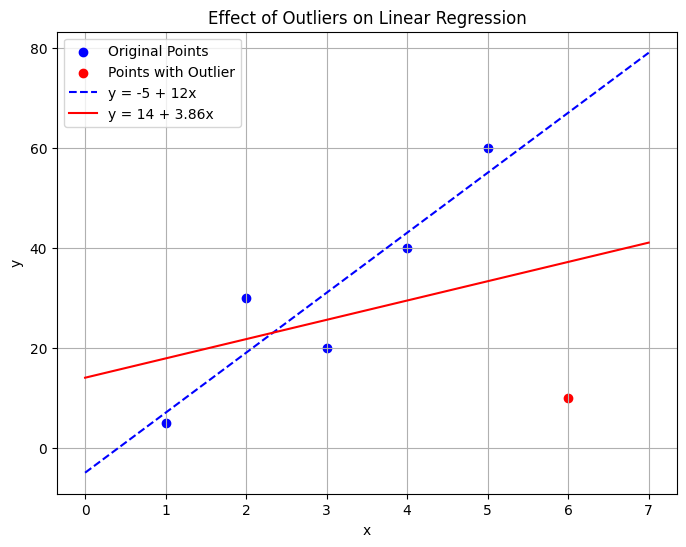

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Original data
x1 = np.array([1, 2, 3, 4, 5])
y1 = np.array([5, 30, 20, 40, 60])

df = pd.DataFrame({"X": x1, "Y": y1})
print(f"df = \n{df.to_string(index=False)}")

# New data with outlier
x2 = 6 
y2 = 10 
print(f"outlier point = ({x2},{y2})")

# Regression lines
x_vals = np.linspace(0, 7, 100)
y_pred1 = -5 + 12 * x_vals  # Original regression line
y_pred2 = 14 + 3.86 * x_vals  # Regression line with outlier

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x1, y1, color='blue', label='Original Points')
plt.scatter(x2, y2, color='red', label='Points with Outlier')

plt.plot(x_vals, y_pred1, color='blue', linestyle='dashed', label='y = -5 + 12x')
plt.plot(x_vals, y_pred2, color='red', linestyle='solid', label='y = 14 + 3.86x')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Effect of Outliers on Linear Regression')
plt.legend()
plt.grid()
plt.show()
